In [2]:
import sys
sys.path.append('../src')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, precision_recall_curve

from dataset import build_image_path_map, ChestXrayDataset, DISEASE_LIST
from model import build_resnet50

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)

image_map = build_image_path_map('../data/raw', cache_path='../data/processed/image_path_map.json')
test_df = pd.read_csv('../data/processed/test_split.csv')
test_dataset = ChestXrayDataset('../data/processed/test_split.csv', image_map, split='test')
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Test set size:", len(test_dataset))

Using device: cuda
Test set size: 16491


#### Cell 2: Load ResNet-50 model and run inference on test set

In [3]:
from model import build_resnet50

resnet_model = build_resnet50(num_classes=14, pretrained=False).to(DEVICE)
resnet_checkpoint = torch.load('../models/resnet50_full_best.pth', map_location=DEVICE, weights_only=False)
resnet_model.load_state_dict(resnet_checkpoint['model_state_dict'])
resnet_model.eval()

print(f"Loaded ResNet-50 checkpoint from epoch {resnet_checkpoint['epoch']+1}, Val AUROC: {resnet_checkpoint['val_macro_auroc']:.4f}")

resnet_all_labels, resnet_all_preds = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = resnet_model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        resnet_all_preds.append(probs)
        resnet_all_labels.append(labels.numpy())

resnet_all_labels = np.concatenate(resnet_all_labels)
resnet_all_preds = np.concatenate(resnet_all_preds)
print("ResNet test predictions shape:", resnet_all_preds.shape)

Loaded ResNet-50 checkpoint from epoch 6, Val AUROC: 0.8357
ResNet test predictions shape: (16491, 14)


#### Cell 3: ResNet-50 Grad-CAM function (architecture-adapted)

In [4]:
def generate_gradcam_resnet(image_tensor, disease_idx, original_pil_image):
    input_tensor = image_tensor.unsqueeze(0).to(DEVICE)
    resnet_model.eval()

    x = resnet_model.conv1(input_tensor)
    x = resnet_model.bn1(x)
    x = resnet_model.relu(x)
    x = resnet_model.maxpool(x)
    x = resnet_model.layer1(x)
    x = resnet_model.layer2(x)
    x = resnet_model.layer3(x)
    features = resnet_model.layer4(x)
    features.retain_grad()

    out = resnet_model.avgpool(features)
    out = torch.flatten(out, 1)
    out = resnet_model.fc(out)

    resnet_model.zero_grad()
    score = out[0, disease_idx]
    score.backward()

    gradients = features.grad
    activations = features.detach()
    weights = gradients.mean(dim=(2, 3), keepdim=True)
    cam = torch.relu((weights * activations).sum(dim=1, keepdim=True))

    cam = cam.squeeze().cpu().numpy()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    cam_resized = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize((224, 224))) / 255.0
    fig_img = np.array(original_pil_image.resize((224, 224))) / 255.0
    heatmap = plt.cm.jet(cam_resized)[:, :, :3]
    overlay = np.clip(0.5 * fig_img + 0.5 * heatmap, 0, 1)

    return overlay

#### Cell 3: Full 14-disease Grad-CAM gallery for ResNet-50 (same structure as DenseNet's Cell 9)

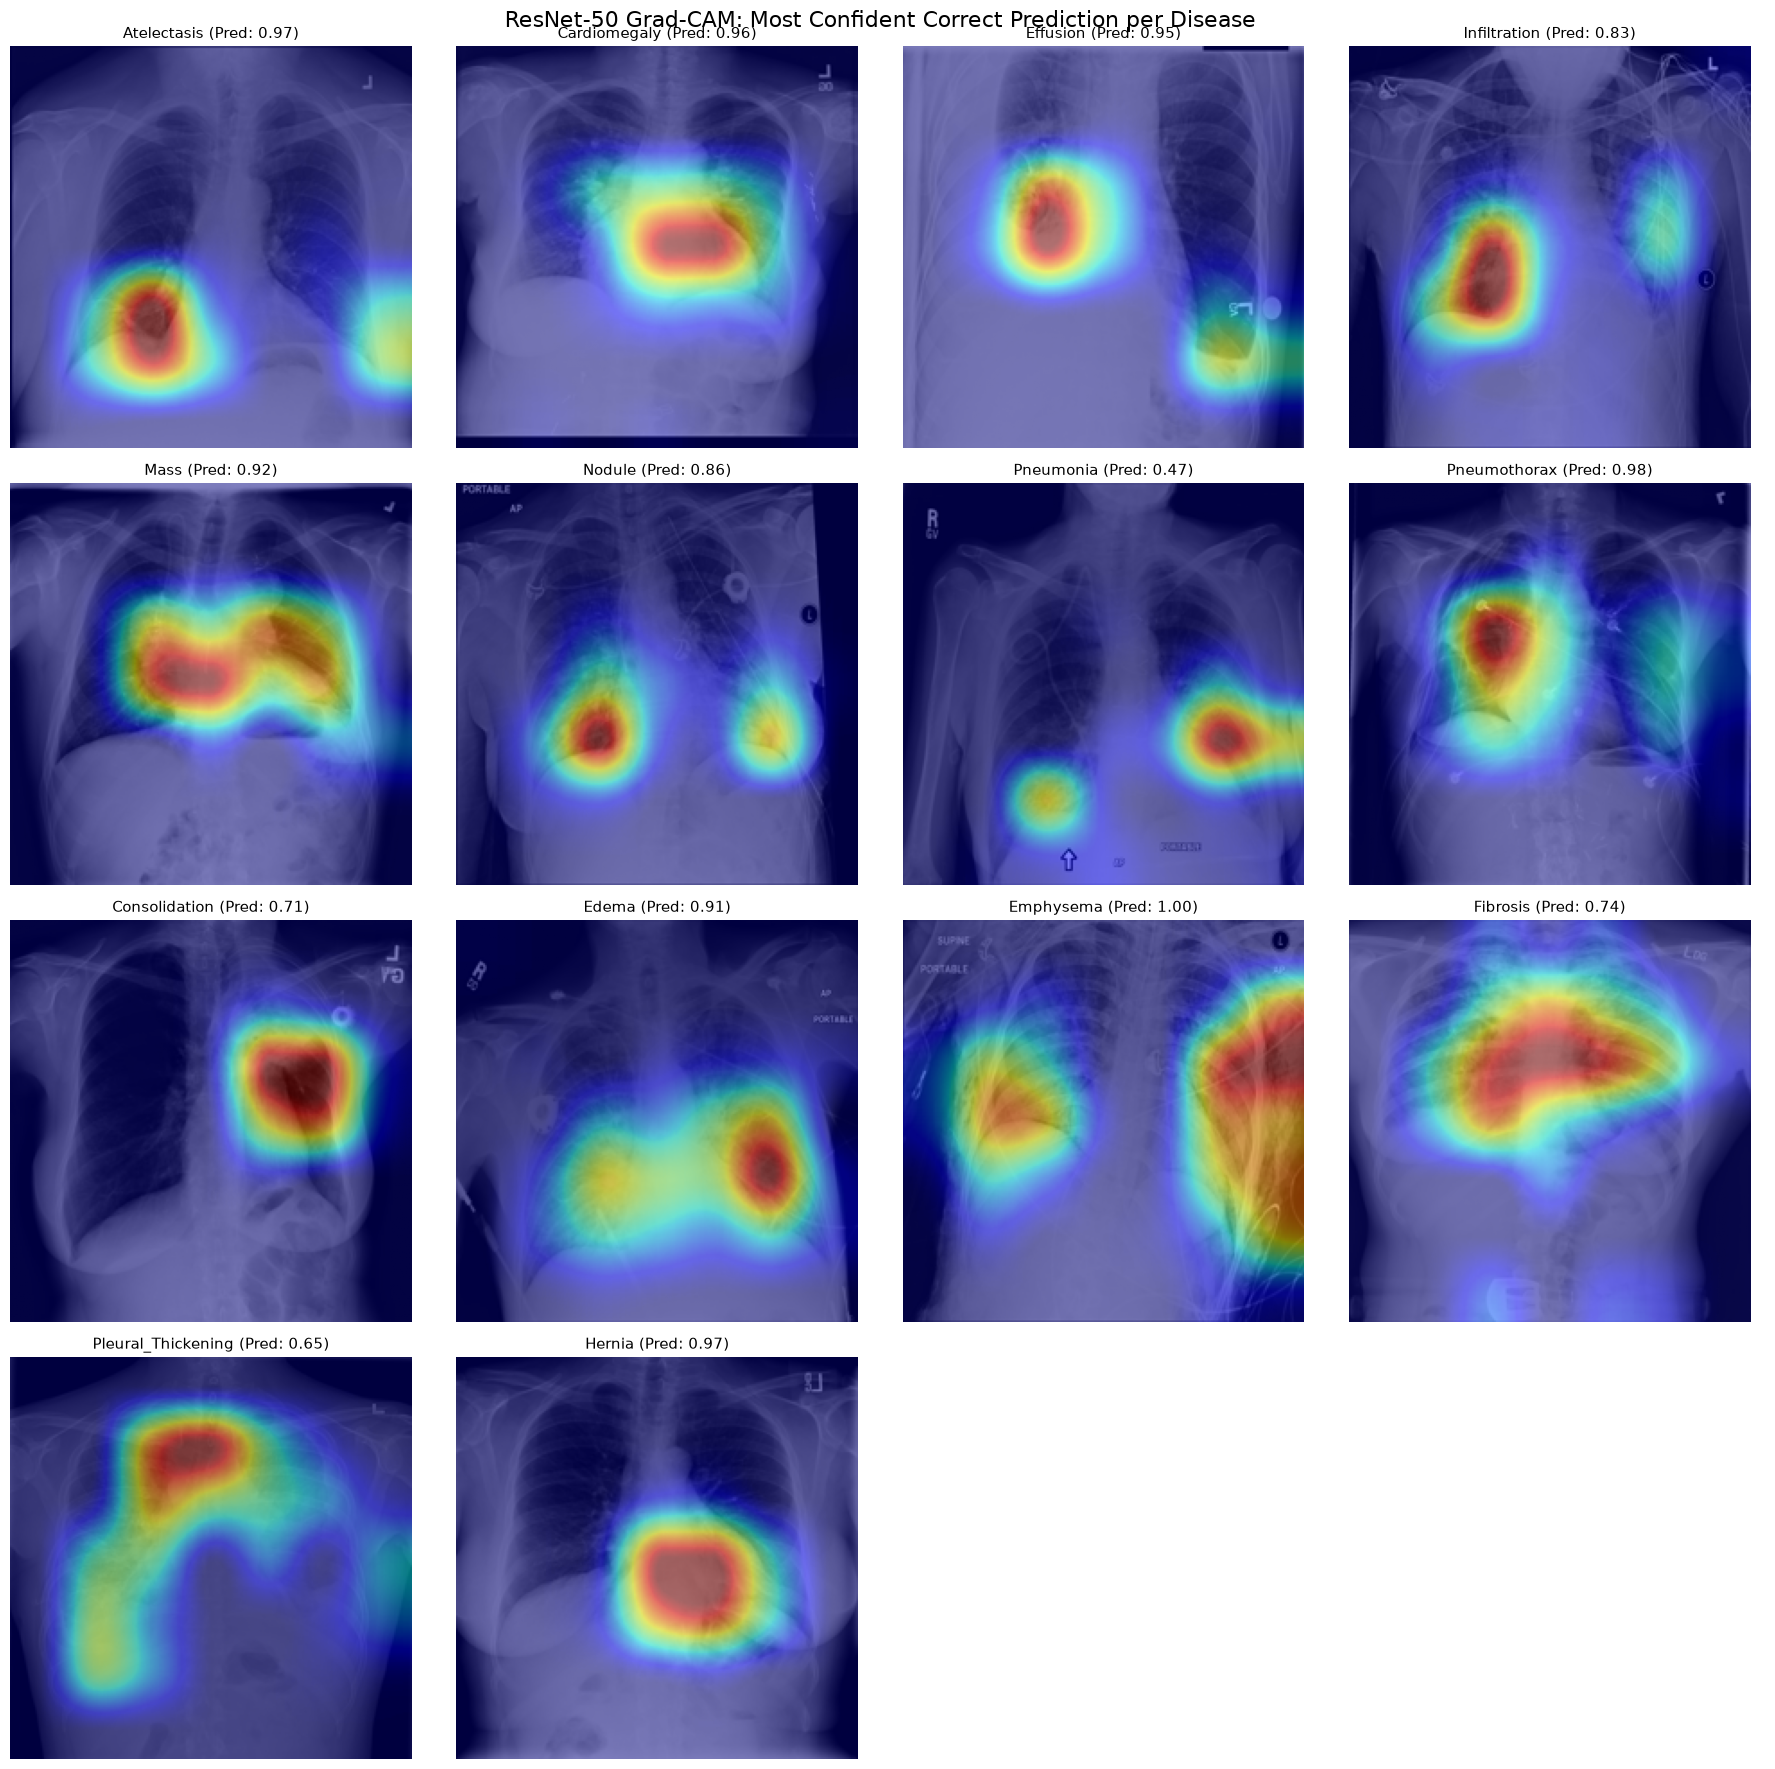

In [5]:
resnet_thresholds = {}
for i, disease in enumerate(DISEASE_LIST):
    if len(np.unique(resnet_all_labels[:, i])) < 2:
        continue
    precisions, recalls, thresholds = precision_recall_curve(resnet_all_labels[:, i], resnet_all_preds[:, i])
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores[:-1])
    resnet_thresholds[disease] = thresholds[best_idx]

fig, axes = plt.subplots(4, 4, figsize=(18, 18))
axes = axes.flatten()

for i, disease in enumerate(DISEASE_LIST):
    idx = DISEASE_LIST.index(disease)
    threshold = resnet_thresholds[disease]
    preds_binary = (resnet_all_preds[:, idx] >= threshold).astype(int)

    correct_positive_mask = (resnet_all_labels[:, idx] == 1) & (preds_binary == 1)
    correct_indices = np.where(correct_positive_mask)[0]

    if len(correct_indices) == 0:
        axes[i].set_title(f"{disease}\n(no confident correct example)")
        axes[i].axis('off')
        continue

    best_idx = correct_indices[np.argmax(resnet_all_preds[correct_indices, idx])]
    fname = test_df.iloc[best_idx]['Image Index']
    original_img = Image.open(image_map[fname]).convert('RGB')
    img_tensor, _ = test_dataset[best_idx]

    heatmap = generate_gradcam_resnet(img_tensor, idx, original_img)

    axes[i].imshow(heatmap)
    axes[i].set_title(f"{disease} (Pred: {resnet_all_preds[best_idx, idx]:.2f})", fontsize=11)
    axes[i].axis('off')

for j in range(len(DISEASE_LIST), len(axes)):
    axes[j].axis('off')

plt.suptitle("ResNet-50 Grad-CAM: Most Confident Correct Prediction per Disease", fontsize=16)
plt.tight_layout()
plt.show()